Size: (303, 384)
Pixel Range: 1 to 252


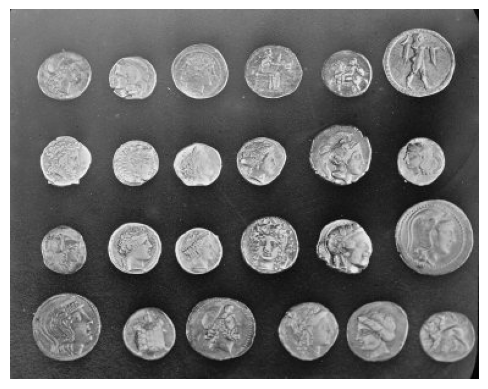

In [33]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import median
from skimage.util import random_noise

img = data.coins()
# Report size and pixel range
print(f"Size: {img.shape}")
print(f"Pixel Range: {img.min()} to {img.max()}")

# Visualize
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

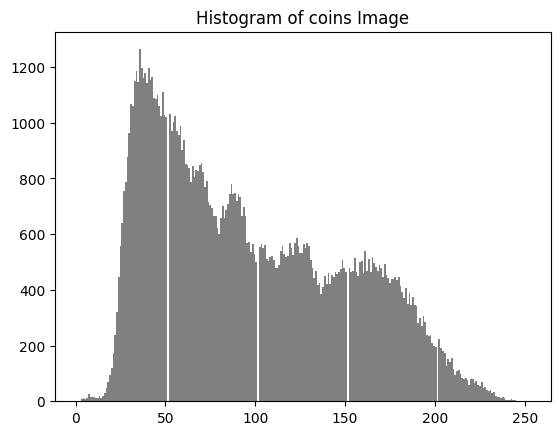

In [38]:
plt.hist(img.ravel(), bins=256, color="gray")
plt.title("Histogram of coins Image")
plt.show()

**Primary Peak (30–50)**: The main peak in the graph shows the background of the image. The background takes up most of the picture. Has a similar gray color so it makes a big spike.

**Broad Distribution (60–180)**: This part of the graph shows the coins. The coins have shades because of reflections, shadows and textures, on their surfaces. That is why this peak is wider and not as tall.

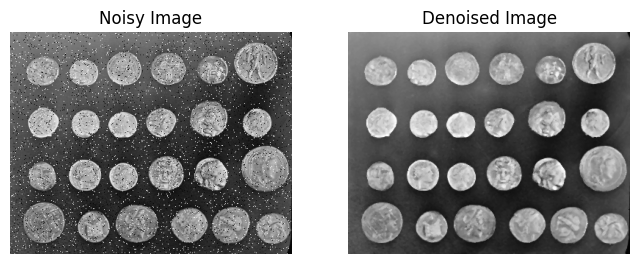

In [42]:

noisy_img = random_noise(img, mode="s&p", amount=0.05)

denoised_img = median(noisy_img)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(noisy_img, cmap="gray")
axes[0].set_title("Noisy Image")
axes[1].imshow(denoised_img, cmap="gray")
axes[1].set_title("Denoised Image")

for ax in axes:
    ax.axis("off")
plt.show()

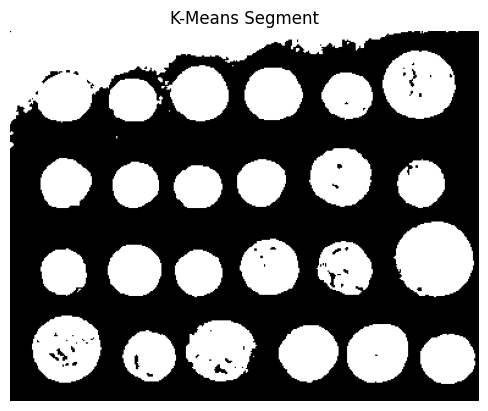

In [39]:
from sklearn.cluster import KMeans


pixel_values = denoised_img.reshape(-1, 1)

kmeans = KMeans(n_clusters=2, random_state=1, n_init=10).fit(pixel_values)

segmented_img = kmeans.labels_.reshape(denoised_img.shape)

plt.imshow(segmented_img, cmap="gray")
plt.title("K-Means Segment")
plt.axis("off")
plt.show()

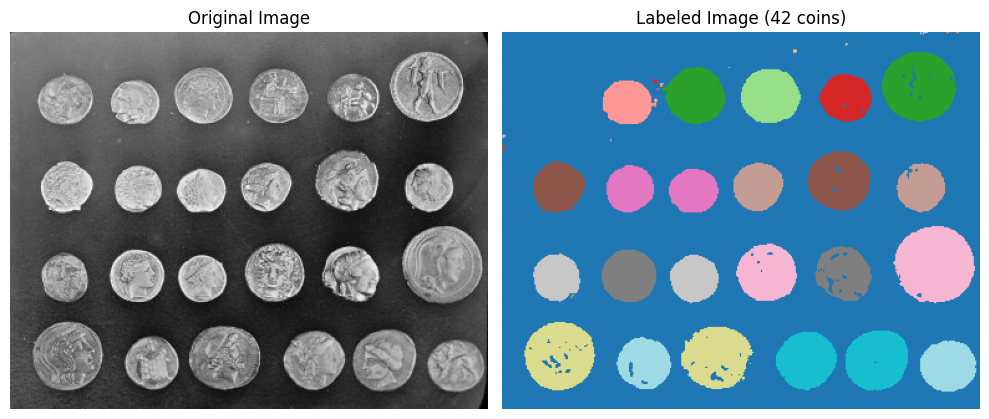

There are 42 coins in the image.


In [45]:
if np.sum(segmented_img == 1) > np.sum(segmented_img ==0):
    binary_mask = np.logical_not(segmented_img)
else:
    binary_mask = segmented_img


labeled_img, num_coins = ndimage.label(binary_mask)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap=plt.cm.gray)
axes[0].set_title("Original Image")
axes[0].axis("off")


axes[1].imshow(labeled_img, cmap=plt.cm.tab20)
axes[1].set_title(f"Labeled Image ({num_coins} coins)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"There are {num_coins} coins in the image.")

In [41]:
print("It reports 42 objects, but there are 23 coins between them!")

It reports 42 objects, but there are 23 coins between them!


Average Area: 1112.31 pixels
Average Major Axis Length: 34.19 pixels
Average Orientation: -0.05 radians


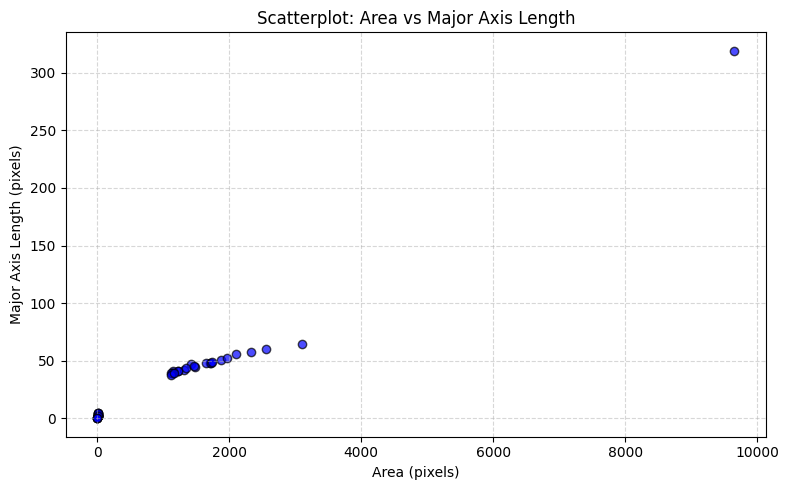

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops


regions = regionprops(labeled_img)


areas = []
major_axes = []
orientations = []

for prop in regions:
    if prop.area < 10000:
        areas.append(prop.area)
        major_axes.append(prop.major_axis_length)
        orientations.append(prop.orientation)


print(f"Average Area: {np.mean(areas):.2f} pixels")
print(f"Average Major Axis Length: {np.mean(major_axes):.2f} pixels")
print(f"Average Orientation: {np.mean(orientations):.2f} radians")


fig, ax = plt.subplots(figsize=(8, 5))


ax.scatter(areas, major_axes, color="blue", alpha=0.7, edgecolors="k")
ax.set_title("Scatterplot: Area vs Major Axis Length")
ax.set_xlabel("Area (pixels)")
ax.set_ylabel("Major Axis Length (pixels)")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

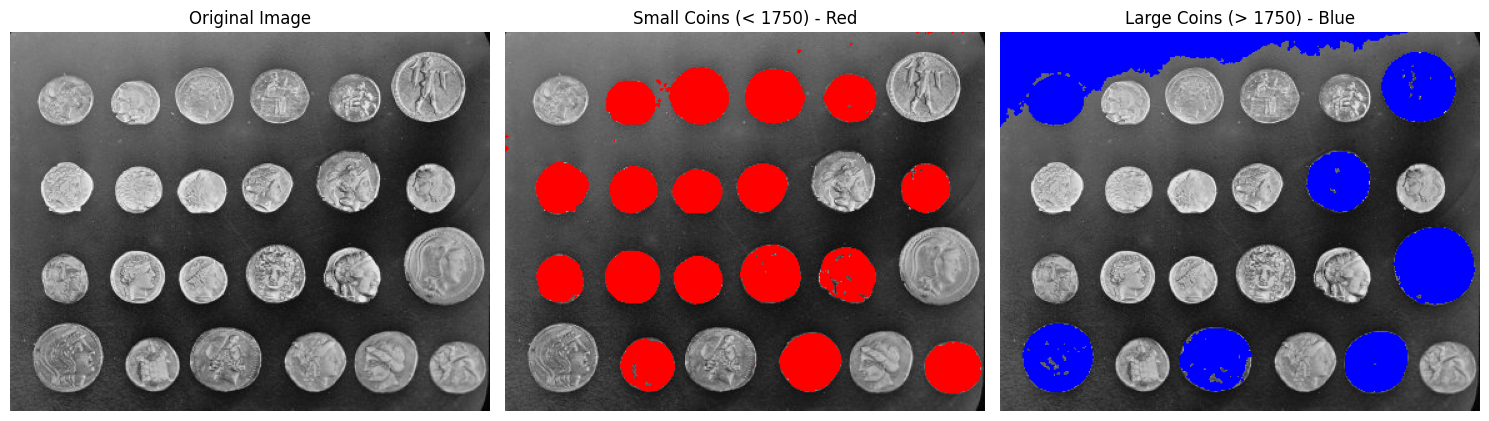

In [48]:
import numpy as np
import matplotlib.pyplot as plt


mask_small = np.zeros_like(labeled_img, dtype=bool)
mask_large = np.zeros_like(labeled_img, dtype=bool)


for prop in regions:
    if prop.area < 10000:
        if prop.area < 1750:
            mask_small[labeled_img == prop.label] = True
        else:
            mask_large[labeled_img == prop.label] = True

img_red_small = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
img_red_small[:, :, 0] = img
img_red_small[:, :, 1] = img
img_red_small[:, :, 2] = img

img_blue_large = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
img_blue_large[:, :, 0] = img
img_blue_large[:, :, 1] = img
img_blue_large[:, :, 2] = img

img_red_small[mask_small] = [255, 0, 0]

img_blue_large[mask_large] = [0, 0, 255]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(img_red_small)
axes[1].set_title("Small Coins (< 1750) - Red")
axes[1].axis("off")

axes[2].imshow(img_blue_large)
axes[2].set_title("Large Coins (> 1750) - Blue")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Image Loading and Preprocessing**

* **Load the RGB image.**

We apply a smoothing filter to the image to remove noise. This helps clustering algorithms work better.

Reshaping (Feature Extraction)

* **An RGB image is like a 3D box with dimensions (Height, Width, 3).**

The "3" is for Red, Green and Blue colors.

We change it into a 2D list so clustering algorithms can use it.

Now each row is a pixel. Has 3 columns for R, G and B values.

**Model. Fitting**

* **We pick a clustering model.**

If it needs the number of clusters we decide based on expected color regions.

We train the model on the 2D pixel array to find color patterns.

Prediction / Label Assignment

* **The model predicts a cluster label for each pixel.**

Each pixel gets a label (0, 1 2) for its color group.

Visualization

* **We reshape the labels back into 2D.**

We can view the labeled mask or replace pixels, with their clusters color to see the segmented image.

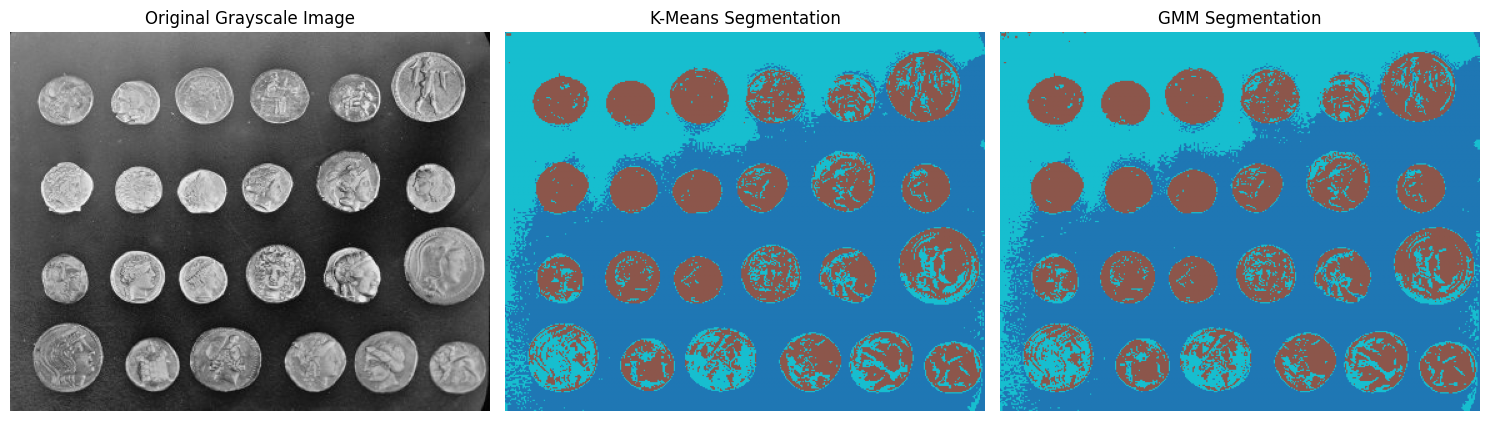

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn import mixture
from sklearn.cluster import KMeans

img = data.coins()

v_img = img.reshape(-1, 1)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10).fit(v_img)
I_kmeans = kmeans.predict(v_img).reshape(img.shape)

gmm = mixture.GaussianMixture(n_components=3, covariance_type='full', random_state=0).fit(v_img)
I_gmm = gmm.predict(v_img).reshape(img.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original Grayscale Image")
axes[0].axis("off")

axes[1].imshow(I_kmeans, cmap=plt.cm.tab10)
axes[1].set_title("K-Means Segmentation")
axes[1].axis("off")

axes[2].imshow(I_gmm, cmap=plt.cm.tab10)
axes[2].set_title("GMM Segmentation")
axes[2].axis("off")

plt.tight_layout()
plt.show()

--- Average GLCM Texture Features ---
Contrast:      435.0948
Dissimilarity: 10.4830
Homogeneity:   0.2040
Energy:        0.0179
Correlation:   0.9224


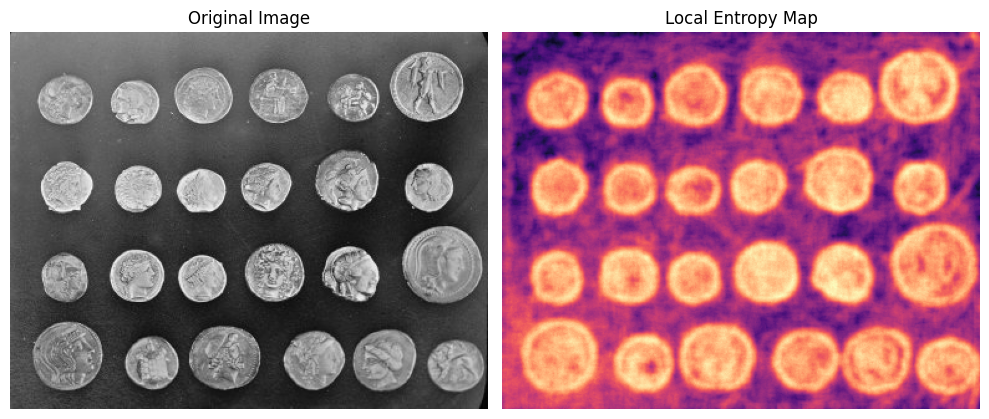

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from skimage.feature import graycomatrix, graycoprops
from skimage.filters.rank import entropy
from skimage.morphology import disk

img = img_as_ubyte(data.coins())

glcm = graycomatrix(img, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                    levels=256, symmetric=True, normed=True)

contrast = graycoprops(glcm, 'contrast')
dissimilarity = graycoprops(glcm, 'dissimilarity')
homogeneity = graycoprops(glcm, 'homogeneity')
energy = graycoprops(glcm, 'energy')
correlation = graycoprops(glcm, 'correlation')

print("--- Average GLCM Texture Features ---")
print(f"Contrast:      {np.mean(contrast):.4f}")
print(f"Dissimilarity: {np.mean(dissimilarity):.4f}")
print(f"Homogeneity:   {np.mean(homogeneity):.4f}")
print(f"Energy:        {np.mean(energy):.4f}")
print(f"Correlation:   {np.mean(correlation):.4f}")

img_entropy = entropy(img, disk(5))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_entropy, cmap='magma')
axes[1].set_title('Local Entropy Map')
axes[1].axis('off')

plt.tight_layout()
plt.show()